# Notebook 03 — Feature Engineering

**Input:** `data/raw/infra_logs.csv`  
**Output:** `data/processed/features.csv`

**Goal:** Transform 7 raw metrics into 42 features that expose anomaly patterns invisible at a single timestamp:
- Raw metric values (7)
- Rolling mean + std over 1-hr and 4-hr windows (28)
- First-difference rate-of-change (7)

> **Label isolation enforced by assertion:** `is_anomaly` / `anomaly_type` are in `labels_df` only, never in `feature_df`.


In [1]:
import sys, os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.insert(0, os.path.join('..', 'src'))
from feature_engineering import build_feature_table, NUMERIC_COLS, LABEL_COLS, ROLLING_WINDOWS

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

raw_df = pd.read_csv('../data/raw/infra_logs.csv', parse_dates=['timestamp'])
print('Raw data shape:', raw_df.shape)
raw_df.head(3)


Raw data shape: (43200, 12)


,timestamp,server_id,service_type,cpu_utilization_pct,memory_utilization_pct,disk_io_mbps,network_latency_ms,response_time_ms,error_rate_pct,requests_per_min,is_anomaly,anomaly_type
0,2024-01-01,srv-api-01,API Gateway,16.098757,18.896329,5.865375,6.294908,28.469177,0.268043,185.616935,0,none
1,2024-01-01,srv-api-02,API Gateway,8.767012,8.879834,3.442270,3.475358,2.410288,0.000000,171.661973,0,none
2,2024-01-01,srv-api-03,API Gateway,11.704922,9.161732,6.433128,5.427398,4.974916,0.373831,198.705855,0,none


## 1. Run the Full Feature Engineering Pipeline


In [2]:
feature_df, labels_df = build_feature_table(
    raw_df,
    output_path='../data/processed/features.csv'
)


Input shape: (43200, 12)
Step 1: Computing rolling statistics (1-hr, 4-hr)...


Step 2: Computing rate-of-change (first difference)...
Step 3: Dropped 225 rows with NaN (first 15 per server). Remaining: 42,975
Step 4: Normalising 42 features per server...



[SAVED] features.csv -> C:\Users\Pyramid\Desktop\NewProjects\infra-anomaly-detection\data\processed\features.csv
Feature matrix shape : (42975, 42)
Feature columns      : 42
  - Raw metrics      : 7
  - Rolling features : 28
  - Diff features    : 7
Label columns kept   : ['is_anomaly', 'anomaly_type']  (NOT in feature matrix)


## 2. Label Isolation Assertion

This assertion is the programmatic guarantee that the feature matrix never contains ground-truth labels.
If it fails, the unsupervised project integrity is broken.


In [3]:
# CRITICAL: ensure no label leakage into the feature matrix
for col in LABEL_COLS:
    assert col not in feature_df.columns, f'LABEL LEAK: {col} found in feature_df!'

print('Assertion passed: is_anomaly and anomaly_type are NOT in the feature matrix.')
print(f'Feature matrix shape: {feature_df.shape}')
print(f'Labels shape        : {labels_df.shape}')


Assertion passed: is_anomaly and anomaly_type are NOT in the feature matrix.
Feature matrix shape: (42975, 42)
Labels shape        : (42975, 5)


## 3. Feature Matrix Overview


In [4]:
print('Feature columns (42 total):')
for i, col in enumerate(feature_df.columns, 1):
    print(f'  {i:2d}. {col}')


Feature columns (42 total):
   1. cpu_utilization_pct
   2. memory_utilization_pct
   3. disk_io_mbps
   4. network_latency_ms
   5. response_time_ms
   6. error_rate_pct
   7. requests_per_min
   8. cpu_utilization_pct_roll_mean_1h
   9. memory_utilization_pct_roll_mean_1h
  10. disk_io_mbps_roll_mean_1h
  11. network_latency_ms_roll_mean_1h
  12. response_time_ms_roll_mean_1h
  13. error_rate_pct_roll_mean_1h
  14. requests_per_min_roll_mean_1h
  15. cpu_utilization_pct_roll_mean_4h
  16. memory_utilization_pct_roll_mean_4h
  17. disk_io_mbps_roll_mean_4h
  18. network_latency_ms_roll_mean_4h
  19. response_time_ms_roll_mean_4h
  20. error_rate_pct_roll_mean_4h
  21. requests_per_min_roll_mean_4h
  22. cpu_utilization_pct_roll_std_1h
  23. memory_utilization_pct_roll_std_1h
  24. disk_io_mbps_roll_std_1h
  25. network_latency_ms_roll_std_1h
  26. response_time_ms_roll_std_1h
  27. error_rate_pct_roll_std_1h
  28. requests_per_min_roll_std_1h
  29. cpu_utilization_pct_roll_std_4h
  30

In [5]:
print('Feature matrix statistics (z-score normalised — all should be near mean=0, std=1):')
stats = feature_df.describe().T[['mean', 'std', 'min', 'max']].round(3)
print(stats.to_string())


Feature matrix statistics (z-score normalised — all should be near mean=0, std=1):
                                     mean  std     min     max
cpu_utilization_pct                   0.0  1.0  -1.804   7.018
memory_utilization_pct               -0.0  1.0  -1.644   3.791
disk_io_mbps                         -0.0  1.0  -1.760   8.849
network_latency_ms                   -0.0  1.0  -1.675  17.236
response_time_ms                     -0.0  1.0  -1.509  13.634
error_rate_pct                       -0.0  1.0  -1.150  33.106
requests_per_min                      0.0  1.0  -1.637   3.649
cpu_utilization_pct_roll_mean_1h     -0.0  1.0  -1.472   6.668
memory_utilization_pct_roll_mean_1h  -0.0  1.0  -1.375   3.851
disk_io_mbps_roll_mean_1h            -0.0  1.0  -1.466   9.172
network_latency_ms_roll_mean_1h       0.0  1.0  -1.579  10.602
response_time_ms_roll_mean_1h         0.0  1.0  -1.595  11.185
error_rate_pct_roll_mean_1h          -0.0  1.0  -1.466  23.373
requests_per_min_roll_mean_1h      

## 4. Visualise Rolling Features — Memory Leak Signature

The 4-hr rolling mean should clearly reveal the gradual memory climb of a `memory_leak` event,
even though no single reading looks extreme.


Visualising memory_leak on: srv-web-02


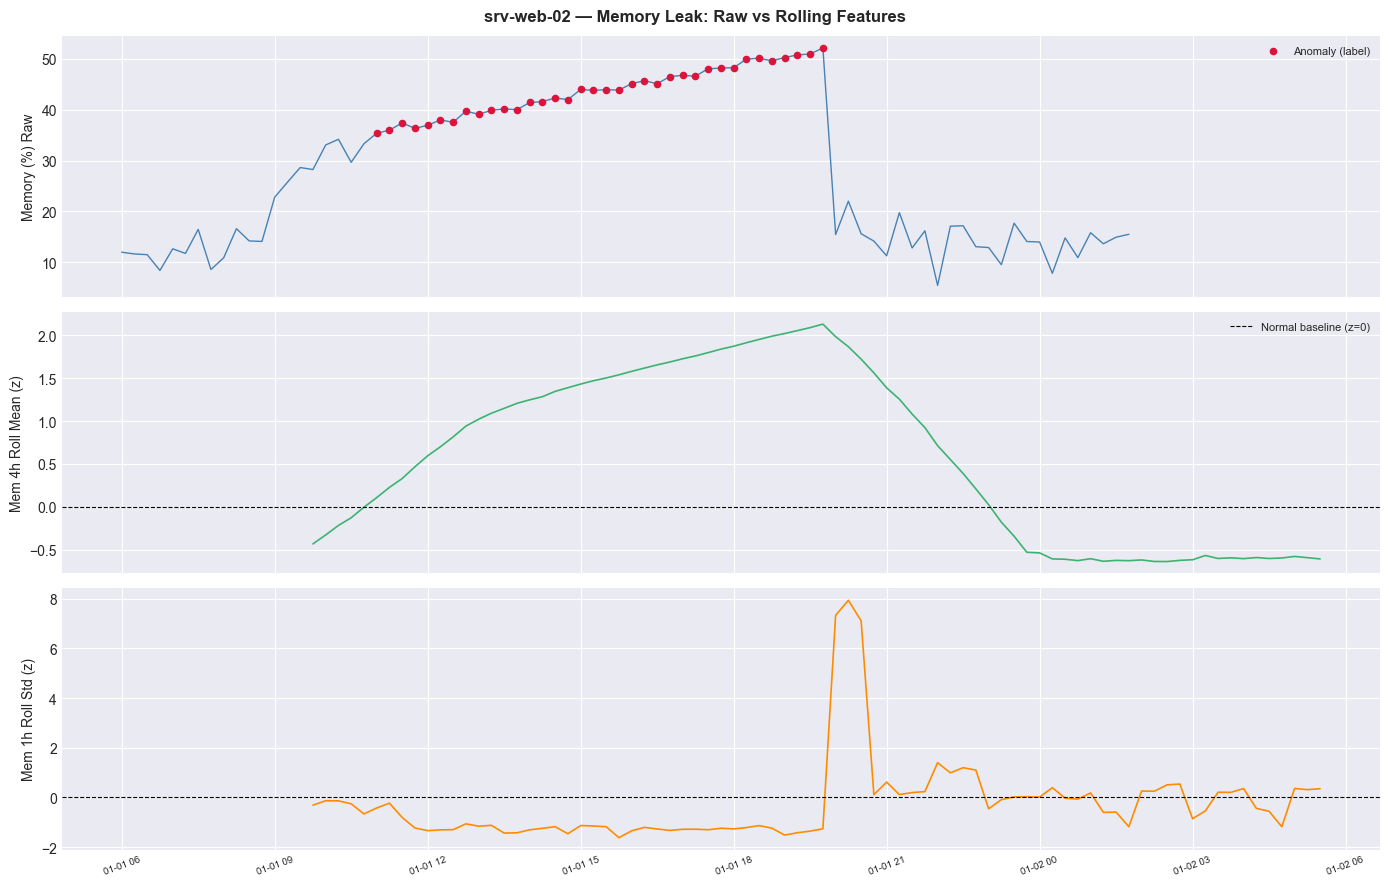

Saved: feat_memory_leak_rolling.png


In [6]:
# Find a server with a memory_leak event
leak_rows = raw_df[raw_df['anomaly_type'] == 'memory_leak']
leak_server = leak_rows['server_id'].mode()[0]
print(f'Visualising memory_leak on: {leak_server}')

# Get raw and processed data for that server
srv_raw = raw_df[raw_df['server_id'] == leak_server].copy().reset_index(drop=True)

# Reload features.csv to get the processed values for this server
feat_csv = pd.read_csv('../data/processed/features.csv', parse_dates=['timestamp'])
srv_feat = feat_csv[feat_csv['server_id'] == leak_server].copy().reset_index(drop=True)

# Find start of first memory_leak window
leak_start_idx = srv_raw[srv_raw['anomaly_type'] == 'memory_leak'].index[0]
window_start = max(0, leak_start_idx - 20)
window_end   = min(len(srv_raw), leak_start_idx + 60)

slc_raw  = srv_raw.iloc[window_start:window_end]
slc_feat = srv_feat.iloc[window_start:window_end]

fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)
fig.suptitle(f'{leak_server} — Memory Leak: Raw vs Rolling Features', fontsize=12, fontweight='bold')

# Raw memory
axes[0].plot(slc_raw['timestamp'], slc_raw['memory_utilization_pct'], lw=1.0, color='steelblue')
anom_slc = slc_raw[slc_raw['is_anomaly'] == 1]
axes[0].scatter(anom_slc['timestamp'], anom_slc['memory_utilization_pct'],
                color='crimson', s=20, zorder=5, label='Anomaly (label)')
axes[0].set_ylabel('Memory (%) Raw'); axes[0].legend(fontsize=8)

# 4-hr rolling mean (z-scored) — should show upward trend
axes[1].plot(slc_feat['timestamp'], slc_feat['memory_utilization_pct_roll_mean_4h'],
             lw=1.2, color='mediumseagreen')
axes[1].axhline(0, color='black', lw=0.8, ls='--', label='Normal baseline (z=0)')
axes[1].set_ylabel('Mem 4h Roll Mean (z)'); axes[1].legend(fontsize=8)

# 1-hr rolling std (z-scored) — should increase as memory climbs irregularly
axes[2].plot(slc_feat['timestamp'], slc_feat['memory_utilization_pct_roll_std_1h'],
             lw=1.2, color='darkorange')
axes[2].axhline(0, color='black', lw=0.8, ls='--')
axes[2].set_ylabel('Mem 1h Roll Std (z)')

plt.xticks(rotation=20, fontsize=7)
plt.tight_layout()
plt.savefig('../results/feat_memory_leak_rolling.png', dpi=110, bbox_inches='tight')
plt.show()
print('Saved: feat_memory_leak_rolling.png')


## 5. Visualise Rate-of-Change — CPU Spike Signature

The first-difference `cpu_utilization_pct_diff` should spike sharply at the onset of a `cpu_spike`,
even if the absolute value doesn't look extreme compared to other servers' peak-hour usage.


Visualising cpu_spike on: srv-worker-01


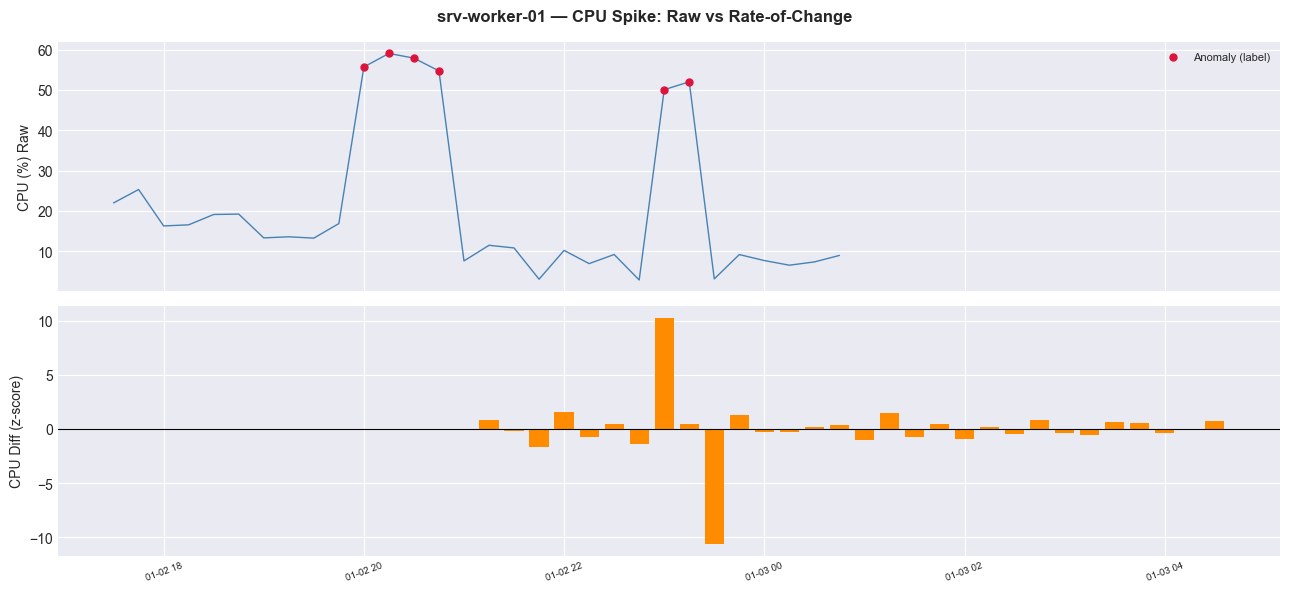

Saved: feat_cpu_spike_diff.png


In [7]:
spike_rows   = raw_df[raw_df['anomaly_type'] == 'cpu_spike']
spike_server = spike_rows['server_id'].mode()[0]
print(f'Visualising cpu_spike on: {spike_server}')

srv_raw2  = raw_df[raw_df['server_id'] == spike_server].copy().reset_index(drop=True)
srv_feat2 = feat_csv[feat_csv['server_id'] == spike_server].copy().reset_index(drop=True)

spike_idx    = srv_raw2[srv_raw2['anomaly_type'] == 'cpu_spike'].index[0]
w_start = max(0, spike_idx - 10)
w_end   = min(len(srv_raw2), spike_idx + 20)

slc_r2 = srv_raw2.iloc[w_start:w_end]
slc_f2 = srv_feat2.iloc[w_start:w_end]

fig, axes = plt.subplots(2, 1, figsize=(13, 6), sharex=True)
fig.suptitle(f'{spike_server} — CPU Spike: Raw vs Rate-of-Change', fontsize=12, fontweight='bold')

axes[0].plot(slc_r2['timestamp'], slc_r2['cpu_utilization_pct'], lw=1.0, color='steelblue')
anom2 = slc_r2[slc_r2['is_anomaly'] == 1]
axes[0].scatter(anom2['timestamp'], anom2['cpu_utilization_pct'],
                color='crimson', s=25, zorder=5, label='Anomaly (label)')
axes[0].set_ylabel('CPU (%) Raw'); axes[0].legend(fontsize=8)

axes[1].bar(slc_f2['timestamp'], slc_f2['cpu_utilization_pct_diff'],
            color='darkorange', width=0.008)
axes[1].axhline(0, color='black', lw=0.8)
axes[1].set_ylabel('CPU Diff (z-score)')

plt.xticks(rotation=20, fontsize=7)
plt.tight_layout()
plt.savefig('../results/feat_cpu_spike_diff.png', dpi=110, bbox_inches='tight')
plt.show()
print('Saved: feat_cpu_spike_diff.png')


## 6. Feature Correlation Heatmap (Sample)

Shows how rolling features relate to raw metrics — confirms the engineered features add
new information rather than being perfectly redundant.


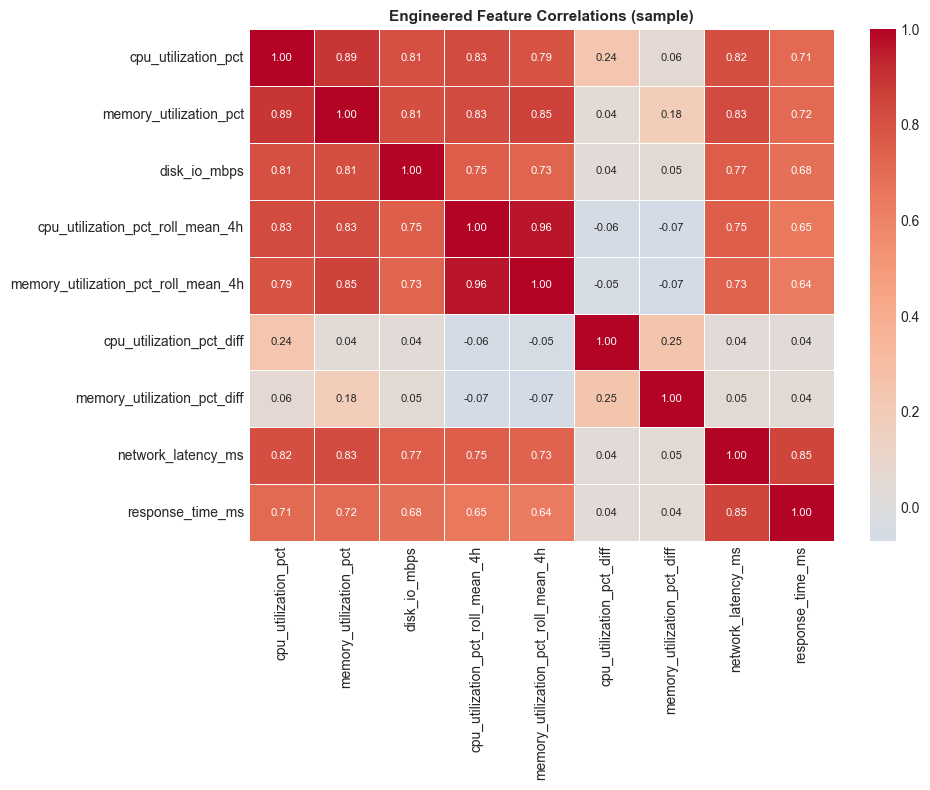

In [8]:
# Sample a subset of features to keep the heatmap readable
sample_cols = (
    ['cpu_utilization_pct', 'memory_utilization_pct', 'disk_io_mbps']
    + ['cpu_utilization_pct_roll_mean_4h', 'memory_utilization_pct_roll_mean_4h']
    + ['cpu_utilization_pct_diff', 'memory_utilization_pct_diff']
    + ['network_latency_ms', 'response_time_ms']
)

corr_feat = feature_df[sample_cols].corr()
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_feat, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, ax=ax, annot_kws={'size': 8})
ax.set_title('Engineered Feature Correlations (sample)', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/feat_correlation.png', dpi=110, bbox_inches='tight')
plt.show()


## 7. Null Check & Final Validation


In [9]:
null_counts = feature_df.isnull().sum()
print('Null values in feature matrix:')
print(null_counts[null_counts > 0] if null_counts.any() else '  None — all clean.')

# Verify z-score normalisation worked (each column should be near mean=0)
col_means = feature_df.mean().abs()
large_means = col_means[col_means > 0.1]
if len(large_means):
    print('WARNING: These columns have |mean| > 0.1 after normalisation:')
    print(large_means)
else:
    print('Normalisation check passed: all column means are near 0.')

print(f'\nFinal feature matrix: {feature_df.shape[0]:,} rows x {feature_df.shape[1]} features')
print(f'Anomaly rate in kept rows: {labels_df["is_anomaly"].mean()*100:.2f}%')
print('\nNext: Run 04_pca_and_clustering.ipynb')


Null values in feature matrix:
  None — all clean.
Normalisation check passed: all column means are near 0.

Final feature matrix: 42,975 rows x 42 features
Anomaly rate in kept rows: 4.70%

Next: Run 04_pca_and_clustering.ipynb
